In [1]:
!pip install langgraph langchain-groq pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.3 MB/s eta 0:00:00


In [20]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
import operator

In [79]:
import os
os.environ["GROQ_API_KEY"]="your api key"

#Schema which we are going to enforce

In [65]:
class Evaluationschema(BaseModel):
  feedback: str = Field(description="detailed feedback for the essay")
  score: int = Field(description="scores for the essay", gt=0, le=10)

# our Structured model

In [66]:
LLM = ChatGroq(model="openai/gpt-oss-20b", temperature=0.7)
structured_model = LLM.with_structured_output(Evaluationschema)

In [67]:
#test
essay = """

The Importance of Reading Books

Reading books is one of the best habits a person can develop.
Books provide knowledge, improve vocabulary, and enhance imagination.
They help us understand different cultures, ideas, and perspectives.
Reading also improves concentration and critical thinking skills.
It is a great way to reduce stress and relax the mind.
Students can perform better in academics by reading regularly.
Books inspire us to achieve our goals and learn from others' experiences.
They are a valuable source of entertainment and lifelong learning.
Everyone should make time to read at least a few pages every day.
A good book can truly change a person's life.

"""

In [68]:
# test:
prompt = f"evaluate the language quality for this essay and give me the score, essay: {essay}"

response = structured_model.invoke(prompt)
print(response)

feedback='The essay is clear and concise, but it lacks depth and variety in sentence structure. It uses simple, declarative sentences and repeats similar ideas without elaboration. The vocabulary is basic and could be enriched with more descriptive words. Additionally, the essay would benefit from transitions and examples to support each claim. Overall, the language quality is adequate for a general audience but falls short of a more polished, sophisticated style.' score=6


# Now we will make our langgraph workflow

In [70]:
class EvaluationState(TypedDict):

  essay: str
  language_feedback: str
  clarity_feedback: str
  analysis_feedback: str
  overall_feedback: str
  individual_score: Annotated[list[int], operator.add]
  avg_score: int

In [71]:
def eval_lang(state: EvaluationState):
  prompt = f"evaluate the essay based on the language quiality used in that and score it out of 10 {state['essay']}"
  output = structured_model.invoke(prompt)

  return {'language_feedback': output.feedback, 'individual_score': [output.score]}


In [72]:
def eval_clarity(state: EvaluationState):
  prompt = f"evaluate the clarity of the essay and score it out of 10 {state['essay']}"
  output = structured_model.invoke(prompt)

  return {'clarity_feedback': output.feedback, 'individual_score': [output.score]}

In [73]:
def eval_analysis(state: EvaluationState):
  prompt = f"evaluate the analysis of the essay and score it out of 10 {state['essay']}"
  output = structured_model.invoke(prompt)

  return {'analysis_feedback': output.feedback, 'individual_score': [output.score]}

In [74]:
def eval_final(state: EvaluationState):
  prompt = f"""summarize these feedback coming from language quality \n {state['language_feedback']}
  clarity of langauge \n {state['clarity_feedback']}
  analysis of the essay \n {state['analysis_feedback']}
  """
  overall_feedback = structured_model.invoke(prompt)
  avg_score = sum(state['individual_score'])/len(state['individual_score'])
  return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [75]:
# creating the graph
graph = StateGraph(EvaluationState)

# nodes for the graph
graph.add_node('evaluation_language', eval_lang)
graph.add_node('evaluation_clarity', eval_clarity)
graph.add_node('evaluation_analysis', eval_analysis)
graph.add_node('evaluation_overall_feedback', eval_final)

graph.add_edge(START,'evaluation_language')
graph.add_edge(START,'evaluation_clarity')
graph.add_edge(START,'evaluation_analysis')

graph.add_edge('evaluation_language', 'evaluation_overall_feedback')
graph.add_edge('evaluation_clarity', 'evaluation_overall_feedback')
graph.add_edge('evaluation_analysis', 'evaluation_overall_feedback')

graph.add_edge('evaluation_overall_feedback', END)

In [76]:
# compiling the graoh
workflow = graph.compile()

In [77]:
# executing the graph
initial_state = {'essay': essay}
final_state = workflow.invoke(initial_state)

In [78]:
print(final_state)

{'essay': "\n\nThe Importance of Reading Books\n\nReading books is one of the best habits a person can develop.\nBooks provide knowledge, improve vocabulary, and enhance imagination.\nThey help us understand different cultures, ideas, and perspectives.\nReading also improves concentration and critical thinking skills.\nIt is a great way to reduce stress and relax the mind.\nStudents can perform better in academics by reading regularly.\nBooks inspire us to achieve our goals and learn from others' experiences.\nThey are a valuable source of entertainment and lifelong learning.\nEveryone should make time to read at least a few pages every day.\nA good book can truly change a person's life.\n\n", 'language_feedback': 'The essay demonstrates clear, concise language with a positive tone, but it lacks variety in sentence structure and depth. The ideas are presented in a straightforward, almost bullet‑point style, which can feel repetitive. While the vocabulary is appropriate and the message 

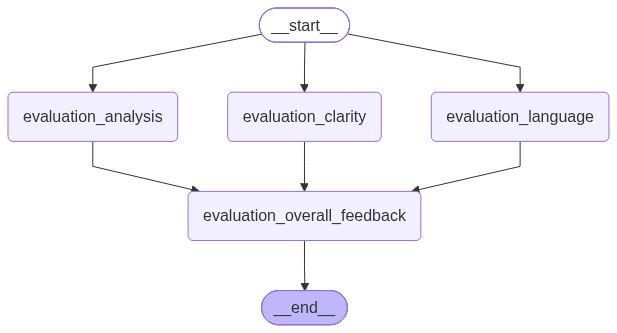

In [45]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())